In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from matplotlib import rc
rc('font', family='Malgun Gothic')

CIFAR-10 데이터셋 로드 중...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.5632443].


CIFAR-10 데이터셋 로드 완료
훈련 데이터: 50000개
테스트 데이터: 10000개

CIFAR-10 샘플 이미지들:


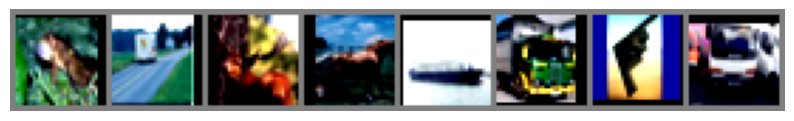

클래스:  frog truck  deer horse  ship truck  plan truck

이미지 크기: torch.Size([3, 32, 32])
배치 크기: 128
클래스 개수: 10


In [3]:
# 데이터 전처리 정의
transform_train = transforms.Compose([      # 데이터 증강
    transforms.RandomCrop(32, padding=4),   # 크롭
    transforms.RandomHorizontalFlip(),      # 수평 뒤집기
    transforms.ToTensor(),                  # PIL 이미지를 텐서로 변환
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)) # 정규화
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])
# 데이터셋 불러오기
print("CIFAR-10 데이터셋 로드 중...")
try:
    train_dataset = datasets.CIFAR10(
        root='../data', train=True, download=False, transform=transform_train)
    test_dataset = datasets.CIFAR10(
        root='../data', train=False, download=False, transform=transform_test)
    # 데이터로더 생성
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False, num_workers=0)
    print(f"CIFAR-10 데이터셋 로드 완료")
    print(f"훈련 데이터: {len(train_dataset)}개")
    print(f"테스트 데이터: {len(test_dataset)}개")
except Exception as e:
    print(f"데이터셋 로드 중 오류 발생: {e}")
    print("인터넷 연결을 확인하거나 데이터셋 경로를 확인해 주세요")

# 클래스 이름
classes = ('plan', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
# 이미지 시각화 함수
def imshow(img):
    img = img / 2 + 0.5     # 정규화 해제
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()
# 샘플 이미지 시각화
try:
    dataiter = iter(train_loader)
    images, labels = next(dataiter)
    print("\nCIFAR-10 샘플 이미지들:")
    imshow(torchvision.utils.make_grid(images[:8]))
    print('클래스: ' + ' '.join('%5s' % classes[labels[j]] for j in range(8)))
    # CIFAR-10 데이터셋 정보 출력
    print(f"\n이미지 크기: {images[0].shape}")
    print(f"배치 크기: {images.shape[0]}")
    print(f"클래스 개수: {len(classes)}")
except Exception as e:
    print(f"이미지 시각화 중 오류 발생: {e}")

In [4]:
# CIFAR-10용 CNN 모델 정의
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super(CIFAR10_CNN, self).__init__()
        # 특성 추출 레이어
        self.features = nn.Sequential(
            # 첫 번째 합성곱
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
            # 두 번째 합성곱
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
            # 세 번째 합성곱
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
        )
        # 분류 레이어
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 모델, 손실 함수, 최적화 초기화
device = torch.device("xpu:0" if torch.xpu.is_available() else "cpu")
cifar_model = CIFAR10_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cifar_model.parameters(), lr=0.001)
print("CIFAR-10 CNN 모델:")
print(cifar_model)

# 모델 파라미터 수
cifar_param = sum(p.numel() for p in cifar_model.parameters())
print(f"\nCIFAR-10 CNN 파라미터 수: {cifar_param:,}")
print(f"사용 디바이스: {device}")

# 간단한 학습 함수 정의
def train_epoch(model, train_loader, criterion, optimizer, device):
    # 1 에포크 학습
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for i, (inputs, labels) in enumerate(train_loader):
        if i >= 10: # 빠른 데모를 위해 10 배치만 학습
            break
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        if i % 5 == 4:
            print(f"배치 {i + 1}, 손실: {running_loss/(i+1):.3f}, 정확도: {100.*correct/total:.2f}%")
    return running_loss/min(i+1, 10), 100.*correct/total

# 평가 함수 정의
def evaluate_model(model, test_loader, criterion, debice):
    # 모델 평가
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            if i >= 5:  # 빠른 데모를 위해 5 배치만 평가
                break
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return test_loss/(i+1), 100.*correct/total

# 간단한 학습 실행(데모용)
try:
    if 'train_loader' in locals():
        print("\n=== 모델 학습 시작 (데모) ===")
        for epoch in range(2):  # 2 에포크만 실행
            print(f"\n에포크 {epoch+1}/2:")
            train_loss, train_acc = train_epoch(cifar_model, train_loader, criterion, optimizer, device)
        
        print("\n=== 모델 평가 ===")
        test_loss, test_acc = evaluate_model(cifar_model, test_loader, criterion, device)
        print(f"테스트 손실: {test_loss:.3f}, 테스트 정확도: {test_acc:.2f}%")
    else:
        print("데이터로더가 준비되지 않아 학습을 건너뜁니다.")
except Exception as e:
    print(f"학습 중 오류 발생: {e}")

CIFAR-10 CNN 모델:
CIFAR10_CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (13): ReLU(inplace=True)
   

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.5632443].


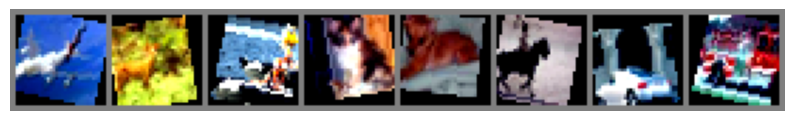

plane  deer  ship   cat   dog horse   car truck


In [8]:
# 이미지 시각화 함수 정의
def imshow(img):
    img = img / 2 + 0.5     # 정규화 해제
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# CIFAR-10 클래스 이름
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 더 다양한 데이터 증강 기법 적용
transform_train_augmented = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),   # 색상 변화
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# 증강된 데이터셋 불러오기
train_dataset_augmented = datasets.CIFAR10(
    root='../data', train=True, download=False, transform=transform_train_augmented)
train_loader_augmented = DataLoader(
    train_dataset_augmented, batch_size=128, shuffle=True, num_workers=2)

# 증강된 샘플 이미지 시각화
dataiter = iter(train_loader_augmented)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:8]))
print(' '.join('%5s' % classes[labels[j]] for j in range(8)))